# Interactive 1D Resonator Explorer

Explore the 1D damped oscillator model from WCFOMA Section 5.3.
Adjust parameters interactively and observe effects on coherence time,
frequency, and damping behavior.

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from simulations.resonator_1d import run_1d_simulation, compute_frequency
from simulations.common import CavityParams, DilatancyParams
from analysis.plotting import apply_style, COLORS

apply_style()
print('1D Resonator Explorer — Ready')

1D Resonator Explorer — Ready


## Parameter Space Exploration

Sweep shear strain from 0 to 0.5 and plot frequency + coherence time.

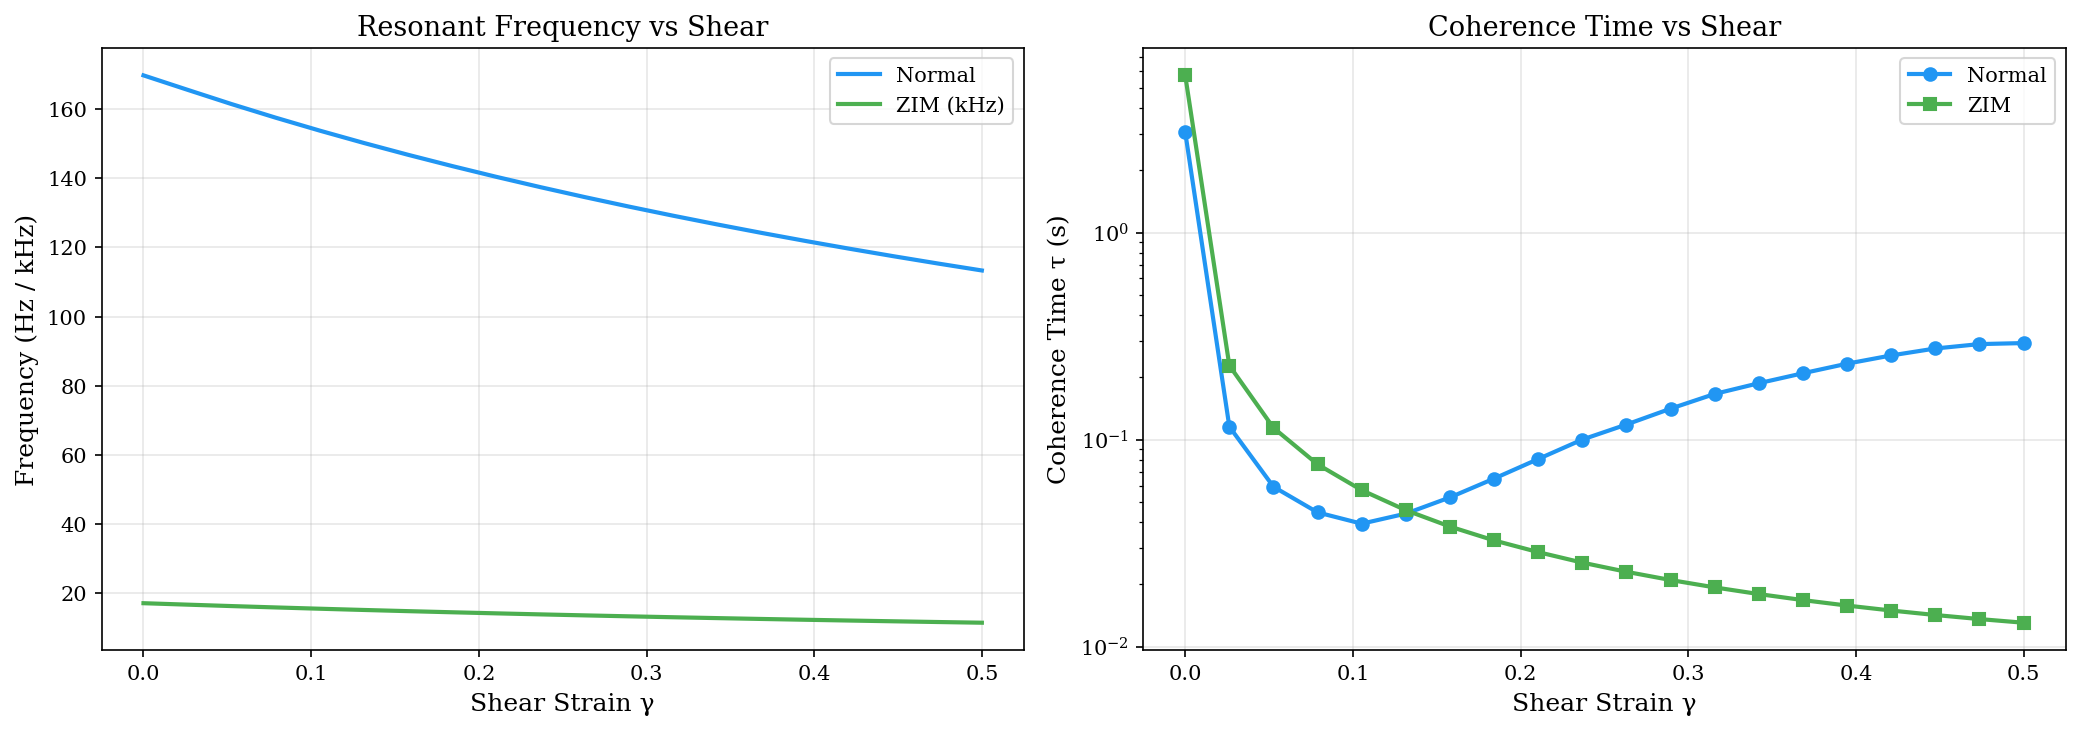

In [8]:
gammas = np.linspace(0, 0.5, 20)

freqs_normal = []
freqs_zim = []
tau_normal = []
tau_zim = []

for g in gammas:
    if g == 0:
        g = 0.001  # Avoid zero damping for measurement
    r_n = run_1d_simulation(L=1.0, c=340, gamma=g, zim=False, t_max=0.1)
    r_z = run_1d_simulation(L=1.0, c=3.4e4, gamma=g, zim=True, t_max=0.1)
    freqs_normal.append(r_n.f_theory)
    freqs_zim.append(r_z.f_theory)
    tau_normal.append(r_n.coherence_time)
    tau_zim.append(r_z.coherence_time)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(gammas, freqs_normal, color=COLORS['normal'], label='Normal')
ax1.plot(gammas, np.array(freqs_zim) / 1e3, color=COLORS['zim'], label='ZIM (kHz)')
ax1.set_xlabel('Shear Strain γ')
ax1.set_ylabel('Frequency (Hz / kHz)')
ax1.set_title('Resonant Frequency vs Shear')
ax1.legend()

ax2.semilogy(gammas, tau_normal, 'o-', color=COLORS['normal'], label='Normal')
ax2.semilogy(gammas, tau_zim, 's-', color=COLORS['zim'], label='ZIM')
ax2.set_xlabel('Shear Strain γ')
ax2.set_ylabel('Coherence Time τ (s)')
ax2.set_title('Coherence Time vs Shear')
ax2.legend()

plt.tight_layout()
plt.show()

## Single Run Deep Dive

Examine time-domain waveform, spectrum, and envelope for a specific case.

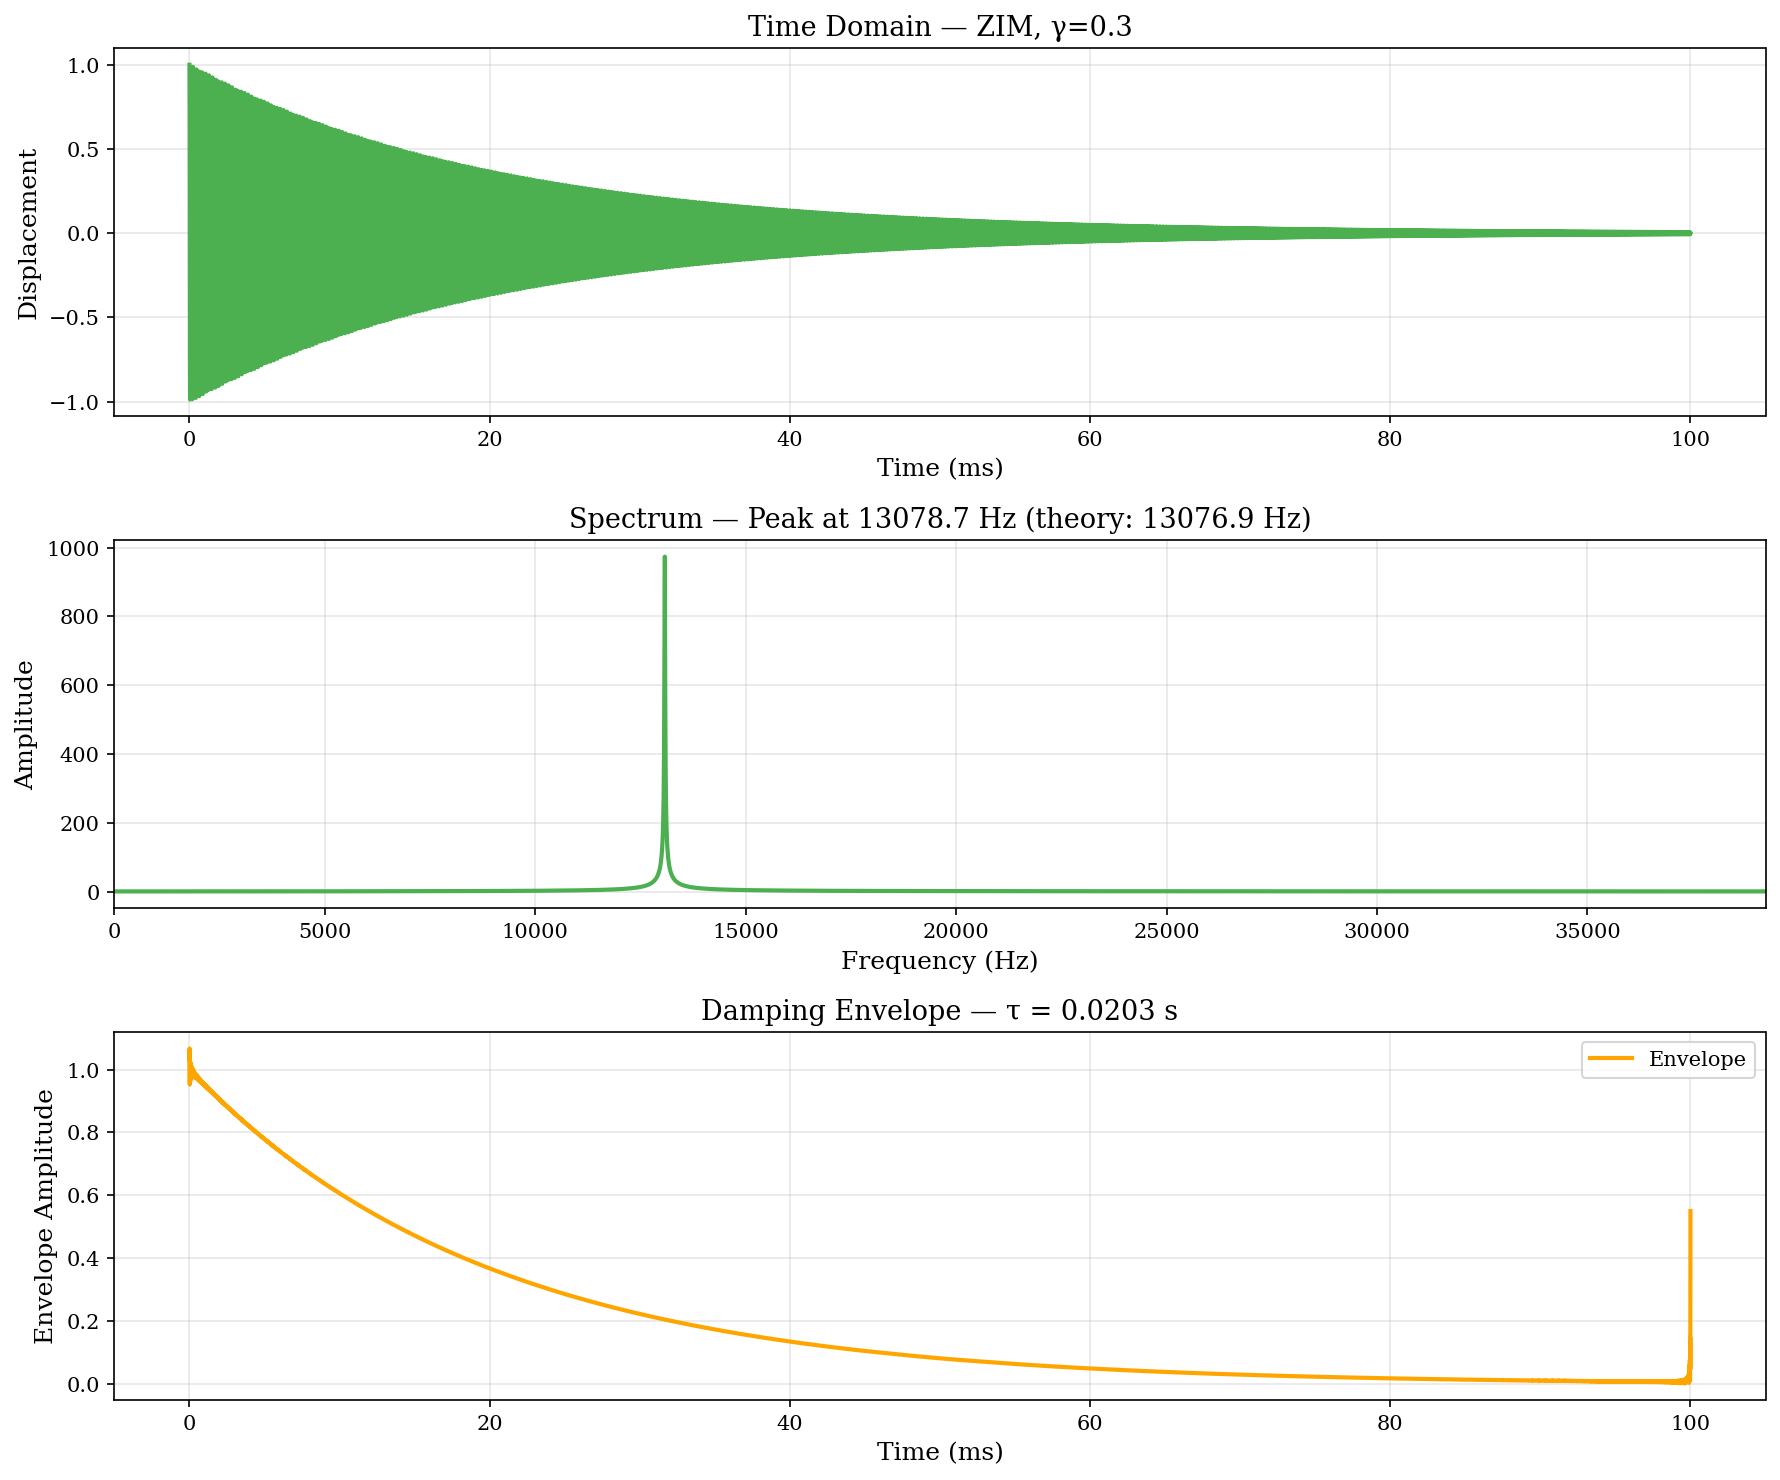

f_theory:    13076.92 Hz
f_simulated: 13078.69 Hz
η_input:     50.00
η_measured:  49.24
τ:           0.0203 s


In [9]:
# Adjust these parameters:
GAMMA = 0.3
USE_ZIM = True
WAVE_SPEED = 3.4e4 if USE_ZIM else 340.0

r = run_1d_simulation(
    L=1.0, c=WAVE_SPEED, gamma=GAMMA,
    zim=USE_ZIM, t_max=0.1, n_points=10000,
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Time domain
axes[0].plot(r.t * 1000, r.x, color=COLORS['zim' if USE_ZIM else 'normal'])
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Displacement')
axes[0].set_title(f'Time Domain — {"ZIM" if USE_ZIM else "Normal"}, γ={GAMMA}')

# Spectrum
from numpy.fft import fft, fftfreq
spec = np.abs(fft(r.x))
freqs = fftfreq(len(r.t), r.t[1] - r.t[0])
pos = freqs > 0
axes[1].plot(freqs[pos], spec[pos], color=COLORS['zim' if USE_ZIM else 'normal'])
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'Spectrum — Peak at {r.f_simulated:.1f} Hz (theory: {r.f_theory:.1f} Hz)')
axes[1].set_xlim(0, r.f_theory * 3)

# Envelope
from scipy.signal import hilbert
env = np.abs(hilbert(r.x - r.x.mean()))
axes[2].plot(r.t * 1000, env, color='orange', label='Envelope')
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Envelope Amplitude')
axes[2].set_title(f'Damping Envelope — τ = {r.coherence_time:.4f} s')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'f_theory:    {r.f_theory:.2f} Hz')
print(f'f_simulated: {r.f_simulated:.2f} Hz')
print(f'η_input:     {r.eta_input:.2f}')
print(f'η_measured:  {r.eta_measured:.2f}')
print(f'τ:           {r.coherence_time:.4f} s')